# 06 Global-average-pool Grad-CAM XAI
This notebook implements Gradient-weighted Class Activation Mapping (Grad-CAM) to provide visual explanations for the pneumonia classifier.
The model is loaded from BentoML and the analysis session is tracked via MLflow.

In [6]:
import os
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2
import bentoml
import mlflow

from pneumonia_classifier.ml.model.arch import Net

# Allow safe unpickling of our custom Net class (PyTorch 2.6+)
torch.serialization.add_safe_globals([Net])

## Load Model from BentoML

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Loading model from BentoML...")
try:
    # Using the latest baseline model
    bento_model = bentoml.pytorch.get("pneumonia_classifier_aug_augmented_heavy:latest")
except Exception:
    print("pneumonia_classifier_aug_augmented_heavy:latest not found. Fetching all models...")
    models = bentoml.models.list()
    if not models:
        raise RuntimeError("No models found in BentoML.")
    # Fallback to the first available model if 'latest' isn't found
    bento_model = models[0]

model = bentoml.pytorch.load_model(bento_model, weights_only=False)
model.to(device)
model.eval()

print(f"Model loaded from BentoML: {bento_model.tag}")

Loading model from BentoML...
Model loaded from BentoML: pneumonia_classifier_aug_augmented_heavy:wypxe3qwqsx75ahb


## Grad-CAM Implementation
We use hooks to extract gradients and activations from the last convolutional layer.

In [9]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # register_full_backward_hook is preferred in modern PyTorch
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_heatmap(self, input_tensor, class_idx=None):
        self.model.zero_grad()
        output = self.model(input_tensor)
        
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
            
        output[0, class_idx].backward()
        
        weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)
        cam = torch.sum(weights * self.activations, dim=1).squeeze()
        
        cam = F.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-7)
        
        return cam.detach().cpu().numpy(), class_idx

## Process and Visualize with MLflow Tracking

In [10]:
def run_explanation(image_path, model, target_layer):
    mlflow.set_experiment("xai_grad_cam")
    
    with mlflow.start_run(run_name=f"grad_cam_{os.path.basename(image_path)}"):
        # Preprocessing
        transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        
        img = Image.open(image_path).convert('RGB')
        input_tensor = transform(img).unsqueeze(0).to(device)
        
        # Generate Cam
        cam_engine = GradCAM(model, target_layer)
        heatmap, predicted_class = cam_engine.generate_heatmap(input_tensor)
        
        # Log to MLflow
        mlflow.log_params({
            "image_path": image_path,
            "predicted_class": "PNEUMONIA" if predicted_class == 1 else "NORMAL",
            "model_version": bento_model.tag
        })
        
        # Visualization
        heatmap = cv2.resize(heatmap, (img.size[0], img.size[1]))
        heatmap = np.uint8(255 * heatmap)
        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
        
        superimposed_img = heatmap * 0.4 + np.array(img)
        superimposed_img = superimposed_img / superimposed_img.max()
        
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.title("Original Image")
        plt.imshow(img)
        plt.axis('off')
        
        plt.subplot(1, 2, 2)
        plt.title(f"Grad-CAM: {'PNEUMONIA' if predicted_class == 1 else 'NORMAL'}")
        plt.imshow(superimposed_img)
        plt.axis('off')
        
        # Save and log chart
        plt.savefig("grad_cam_result.png")
        mlflow.log_artifact("grad_cam_result.png")
        plt.show()


## Example Usage

2026/03/03 11:35:56 INFO mlflow.tracking.fluent: Experiment with name 'xai_grad_cam' does not exist. Creating a new experiment.


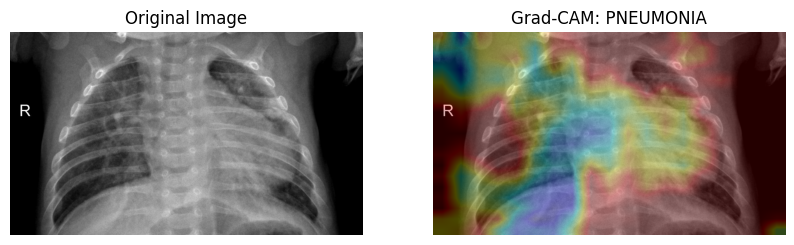

In [11]:
# Example Usage
test_img_path = "../artifacts/02_12_2025_08_52_04/data_ingestion/data/data/train/PNEUMONIA/person1_virus_13.jpeg"

if os.path.exists(test_img_path):
    # convolution_block9 is the last conv layer in Net architecture
    run_explanation(test_img_path, model, model.convolution_block9)
else:
    print(f"Test image not found at {test_img_path}. Searching for fallback images...")
    import glob
    fallbacks = glob.glob("../artifacts/**/*.jpeg", recursive=True)
    if fallbacks:
        print(f"Using fallback image: {fallbacks[0]}")
        run_explanation(fallbacks[0], model, model.convolution_block9)
    else:
        print("No JPEG images found in artifacts directory.")